In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
data=fetch_olivetti_faces()


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\laksh\scikit_learn_data


In [2]:
data.keys()

dict_keys(['data', 'images', 'target', 'DESCR'])

In [4]:
data

{'data': array([[0.30991736, 0.3677686 , 0.41735536, ..., 0.15289256, 0.16115703,
         0.1570248 ],
        [0.45454547, 0.47107437, 0.5123967 , ..., 0.15289256, 0.15289256,
         0.15289256],
        [0.3181818 , 0.40082645, 0.49173555, ..., 0.14049587, 0.14876033,
         0.15289256],
        ...,
        [0.5       , 0.53305787, 0.607438  , ..., 0.17768595, 0.14876033,
         0.19008264],
        [0.21487603, 0.21900827, 0.21900827, ..., 0.57438016, 0.59090906,
         0.60330576],
        [0.5165289 , 0.46280992, 0.28099173, ..., 0.35950413, 0.3553719 ,
         0.38429752]], dtype=float32),
 'images': array([[[0.30991736, 0.3677686 , 0.41735536, ..., 0.37190083,
          0.3305785 , 0.30578512],
         [0.3429752 , 0.40495867, 0.43801653, ..., 0.37190083,
          0.338843  , 0.3140496 ],
         [0.3429752 , 0.41735536, 0.45041323, ..., 0.38016528,
          0.338843  , 0.29752067],
         ...,
         [0.21487603, 0.20661157, 0.2231405 , ..., 0.15289256,
     

In [10]:
data.data.shape
data.target.shape
format(len(np.unique(data.target)))
format(data.images.shape)

'(400, 64, 64)'

In [21]:
def print_faces(images,target,top_n):
    top_n=min(top_n,len(images))
    grid_size=int(np.ceil(np.srt(top_n)))
    fig,axes=plt.subplots(grid_size,grid_size,figsize=(15,15))
    fig.subplots_adjust(left=0,right=1,bottom=0,top=1,hspace=0.2,wspace=0.2)

    for i,ax in enumerate(axes.ravel()):
        if i<top_n:
            ax.imshow(images[i],cmap='bone')
            ax.axis('off')
            ax.text(2,12,sqrt(target[i]),fontsize=9,color='red')
            ax.text(2,55,f"face:{i}",fontsize=9,color='blue')
        else:
            print_faces(data.images,data.target,400)

def display_unique_faces(pics):
    fig=plt.figure(figsize=(24,10))
    for i in range(1,columns*rows+1):
        img_index=10*i-1
        if img_index < pics.shape[0]:
            img=pics[img_index,:,:]
            ax=fig.add_subplot(rows,columns,i)
            ax.imshow(img,cmap='gray')
            ax.set_title(f"Person {i}",fontsize=14)
            ax.axis('off')
    display_unique_faces(data.images)
    plt.suptitle("there are 40 distinct persons inthe dataset",fontsize=24)
    plt.show()

In [22]:
print_faces(data.images,data.target,400)

AttributeError: module 'numpy' has no attribute 'srt'

In [14]:
from sklearn.model_selection import train_test_split
x=data.data
y=data.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
print("X_train:",x_train.shape)
print("x_test:",x_test.shape)


X_train: (280, 4096)
x_test: (120, 4096)


Number of Misclassified images: 31
Total images in the test set: 120
Accuracy: 74.17%


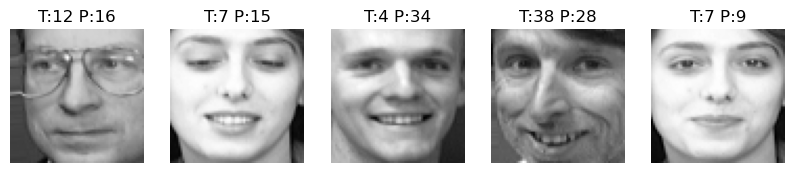


Confusion Matrix:
[[3 0 0 ... 0 0 0]
 [0 3 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 3 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 4]]
Naive Bayes Accuracy: 74.17%


In [17]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Train model
nb = GaussianNB()
nb.fit(x_train, y_train)

# Predict on test data
y_pred = nb.predict(x_test)

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_test)[0]
num_misclassified = len(misclassified_idx)

print(f"Number of Misclassified images: {num_misclassified}")
print(f"Total images in the test set: {len(y_test)}")

# Manual Accuracy
accuracy = (1 - num_misclassified / len(y_test)) * 100
print(f"Accuracy: {round(accuracy, 2)}%")

# 🔥 Detect image size automatically
img_size = int(np.sqrt(x_test.shape[1]))

# Show some misclassified images
n_show = min(num_misclassified, 5)

plt.figure(figsize=(10, 5))
for i in range(n_show):
    idx = misclassified_idx[i]
    plt.subplot(1, n_show, i + 1)
    plt.imshow(x_test[idx].reshape(img_size, img_size), cmap='gray')
    plt.title(f"T:{y_test[idx]} P:{y_pred[idx]}")
    plt.axis('off')

plt.show()

# Sklearn Accuracy + Confusion Matrix
nb_accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print(f"Naive Bayes Accuracy: {nb_accuracy}%")

Multinomial Naive Bayes Accuracy: 75.83%

Confusion Matrix:
[[1 0 0 ... 0 0 0]
 [0 4 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 3 0 0]
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 1 0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       1.00      1.00      1.00         4
           2       0.00      0.00      0.00         2
           3       1.00      0.75      0.86         4
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       1.00      0.33      0.50         3
           7       0.86      0.75      0.80         8
           8       0.67      1.00      0.80         2
           9       0.50      1.00      0.67         3
          10       1.00      1.00      1.00         3
          11       0.67      0.80      0.73         5
          12       1.00      0.50      0.67         2
          13       1.00      1.00      

c:\Users\laksh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laksh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laksh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laksh\anaconda3\Lib\site-pa

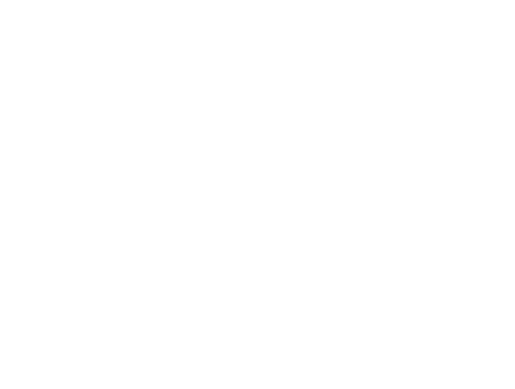

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

# Create model
nb = MultinomialNB()

# Train
nb.fit(x_train, y_train)

# Predict
y_pred = nb.predict(x_test)

# Accuracy
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f"Multinomial Naive Bayes Accuracy: {accuracy}%")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.axis('off')
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
y_test_bin=label_binarize(y_test,classes=np.unique(y_test))
y_pred_prob=nb.predict_proba(x_test)
for i in range(y_test_bin.shape[1]):
    roc_auc=roc_auc_score(y_test_bin[:,i],y_pred_prob[:,i])
    print(f"Class {i} ,AUC :{roc_auc:.2f}")

Keys: dict_keys(['data', 'images', 'target', 'DESCR'])
Data shape: (400, 4096)
Target shape: (400,)
Unique classes: 40
Image shape: (400, 64, 64)


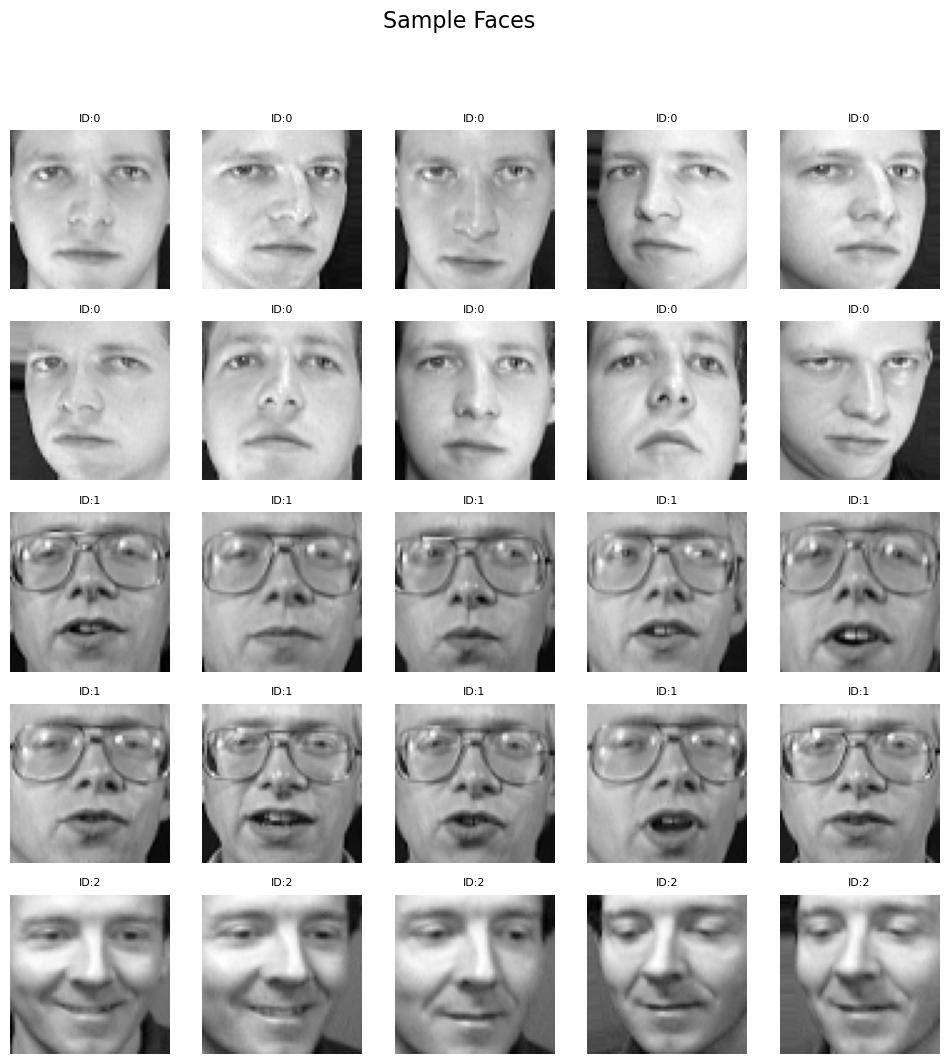

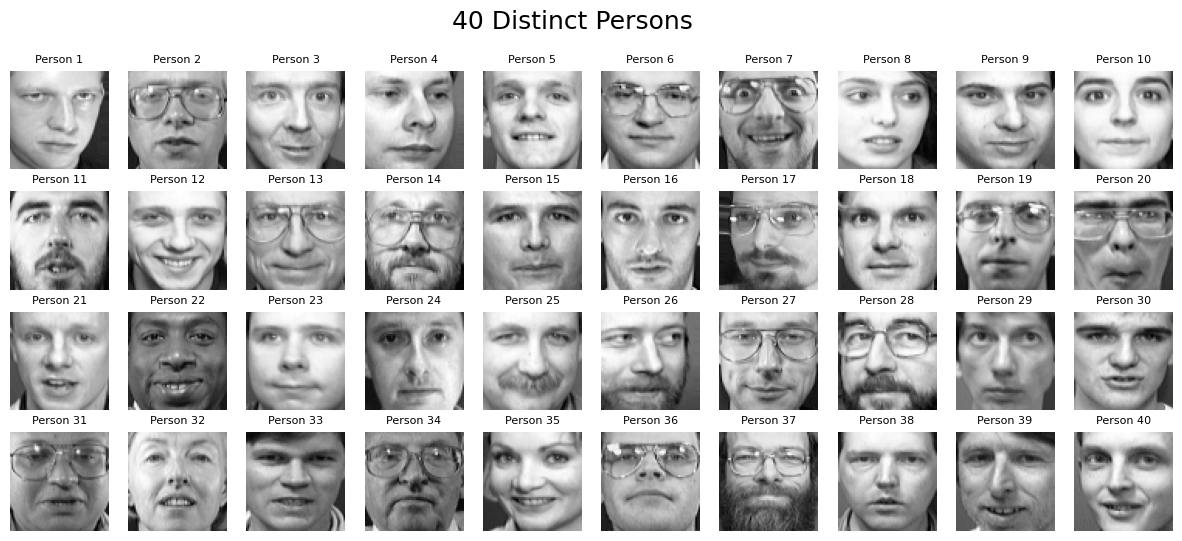

X_train: (280, 4096)
X_test: (120, 4096)

--- Gaussian Naive Bayes ---
Accuracy: 74.17%
Misclassified: 31


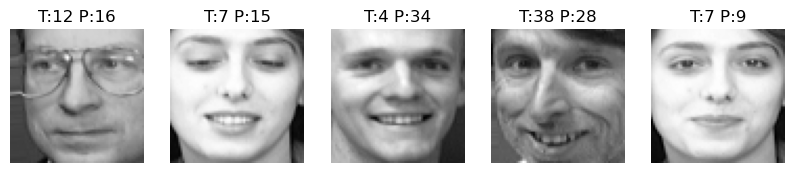


Confusion Matrix:
[[3 0 0 ... 0 0 0]
 [0 3 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 3 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 4]]

--- Multinomial Naive Bayes ---
Accuracy: 75.83%

Confusion Matrix:
[[1 0 0 ... 0 0 0]
 [0 4 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 3 0 0]
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 1 0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       1.00      1.00      1.00         4
           2       0.00      0.00      0.00         2
           3       1.00      0.75      0.86         4
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       1.00      0.33      0.50         3
           7       0.86      0.75      0.80         8
           8       0.67      1.00      0.80         2
           9       0.50      1.00      0.67         3
          10       1.00      1.00      1.00         3

c:\Users\laksh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laksh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laksh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laksh\anaconda3\Lib\site-pa

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# -----------------------------
# 1. LOAD DATA
# -----------------------------
data = fetch_olivetti_faces()

print("Keys:", data.keys())
print("Data shape:", data.data.shape)
print("Target shape:", data.target.shape)
print("Unique classes:", len(np.unique(data.target)))
print("Image shape:", data.images.shape)

# -----------------------------
# 2. VISUALIZATION FUNCTIONS
# -----------------------------
def print_faces(images, target, top_n=25):
    top_n = min(top_n, len(images))
    grid_size = int(np.ceil(np.sqrt(top_n)))

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    axes = axes.ravel()

    for i in range(grid_size * grid_size):
        ax = axes[i]
        if i < top_n:
            ax.imshow(images[i], cmap='gray')
            ax.set_title(f"ID:{target[i]}", fontsize=8)
        ax.axis('off')

    plt.suptitle("Sample Faces", fontsize=16)
    plt.show()


def display_unique_faces(images):
    rows, columns = 4, 10
    fig = plt.figure(figsize=(15, 6))

    for i in range(1, rows * columns + 1):
        img_index = 10 * i - 1
        if img_index < images.shape[0]:
            ax = fig.add_subplot(rows, columns, i)
            ax.imshow(images[img_index], cmap='gray')
            ax.set_title(f"Person {i}", fontsize=8)
            ax.axis('off')

    plt.suptitle("40 Distinct Persons", fontsize=18)
    plt.show()


# Show faces
print_faces(data.images, data.target, 25)
display_unique_faces(data.images)

# -----------------------------
# 3. TRAIN TEST SPLIT
# -----------------------------
X = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("X_train:", x_train.shape)
print("X_test:", x_test.shape)

# -----------------------------
# 4. GAUSSIAN NAIVE BAYES
# -----------------------------
print("\n--- Gaussian Naive Bayes ---")

gnb = GaussianNB()
gnb.fit(x_train, y_train)

y_pred = gnb.predict(x_test)

# Accuracy
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f"Accuracy: {accuracy}%")

# Misclassified
mis_idx = np.where(y_pred != y_test)[0]
print("Misclassified:", len(mis_idx))

# Show misclassified images
img_size = int(np.sqrt(x_test.shape[1]))
n_show = min(5, len(mis_idx))

plt.figure(figsize=(10, 5))
for i in range(n_show):
    idx = mis_idx[i]
    plt.subplot(1, n_show, i + 1)
    plt.imshow(x_test[idx].reshape(img_size, img_size), cmap='gray')
    plt.title(f"T:{y_test[idx]} P:{y_pred[idx]}")
    plt.axis('off')
plt.show()

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 5. MULTINOMIAL NAIVE BAYES
# -----------------------------
print("\n--- Multinomial Naive Bayes ---")

mnb = MultinomialNB()
mnb.fit(x_train, y_train)

y_pred_mnb = mnb.predict(x_test)

accuracy_mnb = round(accuracy_score(y_test, y_pred_mnb) * 100, 2)
print(f"Accuracy: {accuracy_mnb}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_mnb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_mnb))

# -----------------------------
# 6. ROC AUC (Multi-class)
# -----------------------------
print("\n--- ROC AUC Scores ---")

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_pred_prob = mnb.predict_proba(x_test)

for i in range(y_test_bin.shape[1]):
    auc = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    print(f"Class {i} AUC: {auc:.2f}")